In [ ]:
!pip install opencv-python opencv-contrib-python --quiet

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

In [ ]:
# Загрузка файлов
uploaded = files.upload()

Saving morph3.bmp to morph3.bmp
Saving Truck.jpg to Truck.jpg
Saving Morph.jpg to Morph.jpg
Saving morph2.bmp to morph2.bmp
Saving Fingerprint.jpg to Fingerprint.jpg
Saving Bri.jpg to Bri.jpg
Saving Blobs.jpg to Blobs.jpg
Saving Blobs 2.jpg to Blobs 2.jpg


In [ ]:
# Сохраняем загруженные файлы в рабочую папку
for filename in uploaded.keys():
    with open(filename, 'wb') as f:
        f.write(uploaded[filename])
    print(f"Файл '{filename}' сохранён.")

Файл 'morph3.bmp' сохранён.
Файл 'Truck.jpg' сохранён.
Файл 'Morph.jpg' сохранён.
Файл 'morph2.bmp' сохранён.
Файл 'Fingerprint.jpg' сохранён.
Файл 'Bri.jpg' сохранён.
Файл 'Blobs.jpg' сохранён.
Файл 'Blobs 2.jpg' сохранён.


In [ ]:
# Проверяем наличие нужных файлов
expected_files = ['Morph.jpg', 'morph2.bmp', 'morph3.bmp', 'Fingerprint.jpg']
available = [f for f in expected_files if os.path.exists(f)]
print("\nДоступные файлы для работы:", available)


Доступные файлы для работы: ['Morph.jpg', 'morph2.bmp', 'morph3.bmp', 'Fingerprint.jpg']


In [ ]:
# Функция для отображения и сохранения изображений
def show_and_save(img, title, filename, cmap='gray'):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()
    cv2.imwrite(filename, img)

In [ ]:
# Создаём папку для сохранения результатов
os.makedirs('results', exist_ok=True)

Эрозия (cv2.erode) - значение результирующего пикселя равно минимуму (при бинарном — логическое И) среди пикселей изображения, накрываемых ядром, когда его центр совмещён с текущим пикселем.

Дилатация (cv2.dilate) - значение результирующего пикселя равно максимуму (логическое ИЛИ) в окрестности.

In [ ]:
# Задание 1. Дилатация и эрозия (Morph.jpg)
img_morph = cv2.imread('Morph.jpg', cv2.IMREAD_GRAYSCALE)
if img_morph is not None:
    _, img_bin = cv2.threshold(img_morph, 127, 255, cv2.THRESH_BINARY)
else:
    raise FileNotFoundError("Morph.jpg не найден")

In [ ]:
# Определяем структурные элементы (небольшие бинарные изображения (матрицы), которые определяют окрестность пикселя)
sizes = [3, 5]
shapes = {
    'cross': cv2.MORPH_CROSS, # крест
    'rect': cv2.MORPH_RECT, # прямоугольник
    'ellipse': cv2.MORPH_ELLIPSE # эллипс
}
iterations_list = [1, 3, 5]

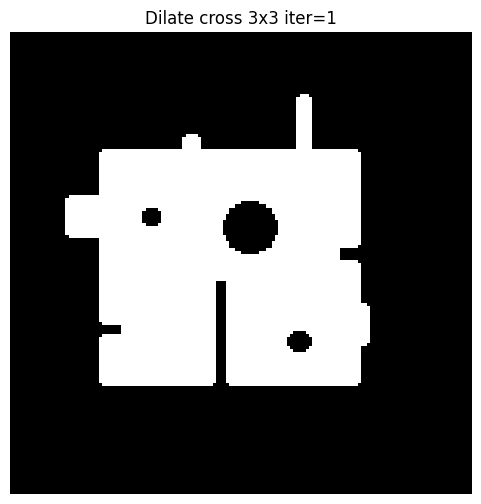

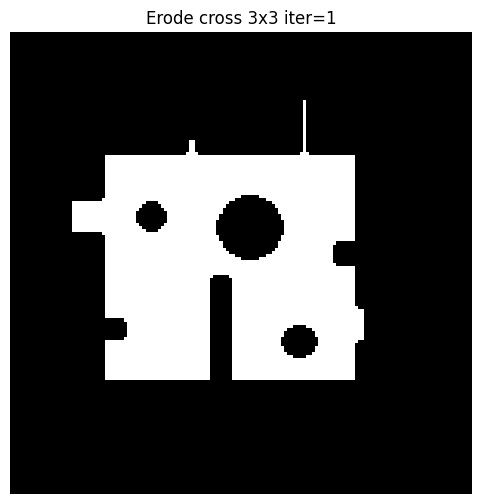

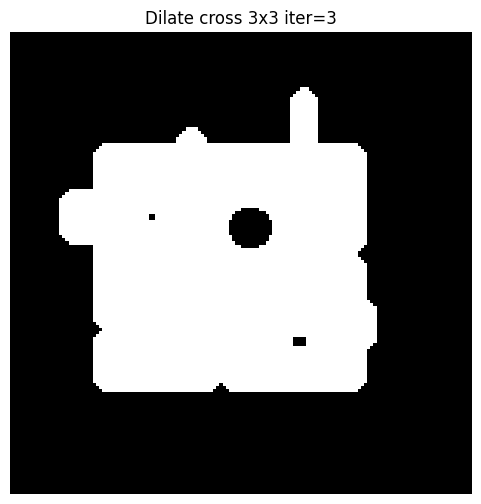

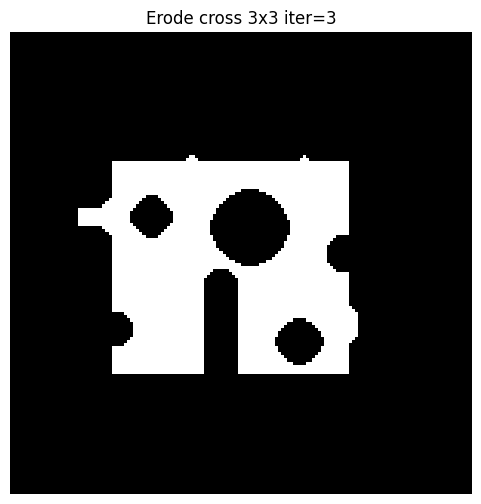

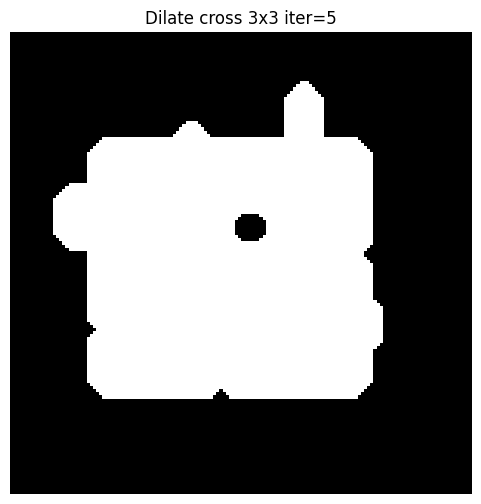

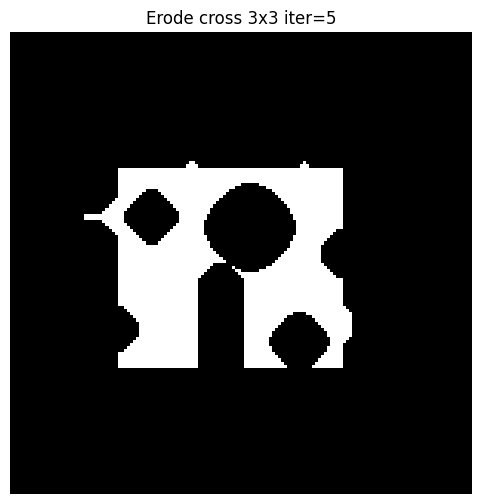

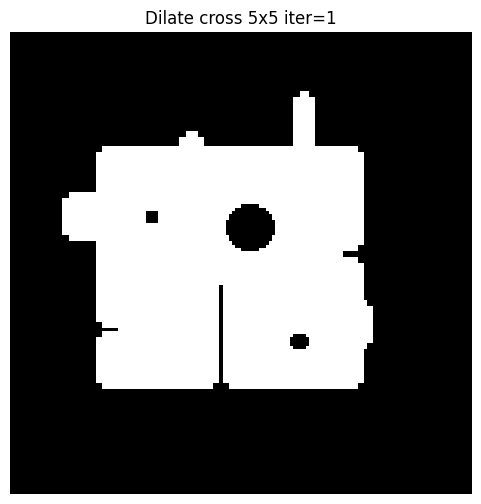

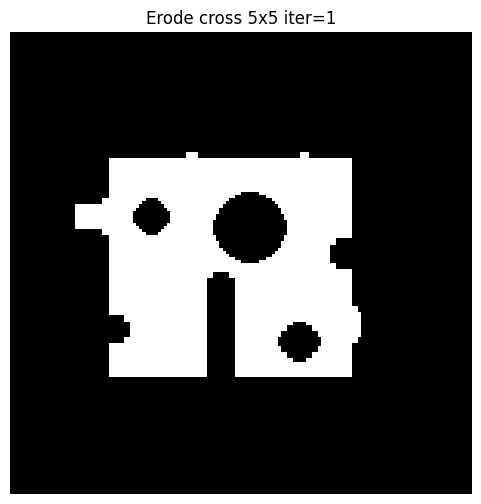

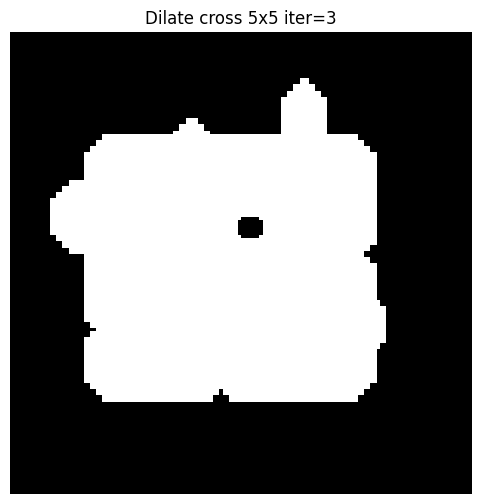

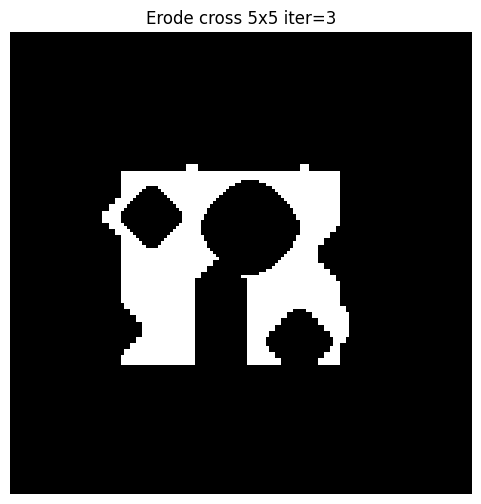

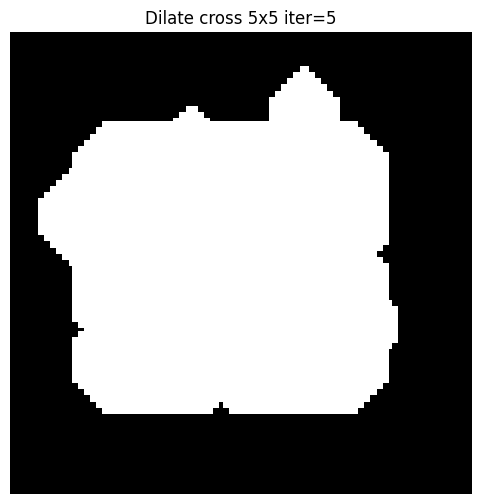

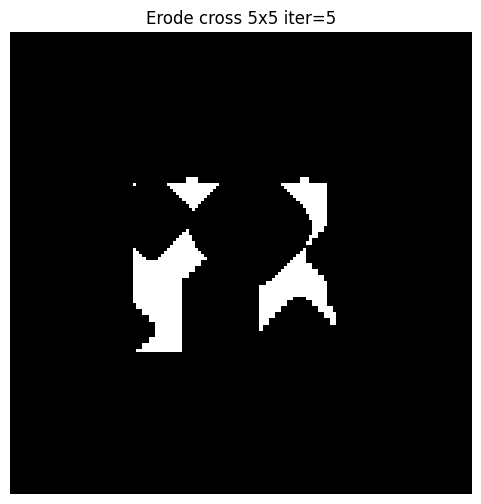

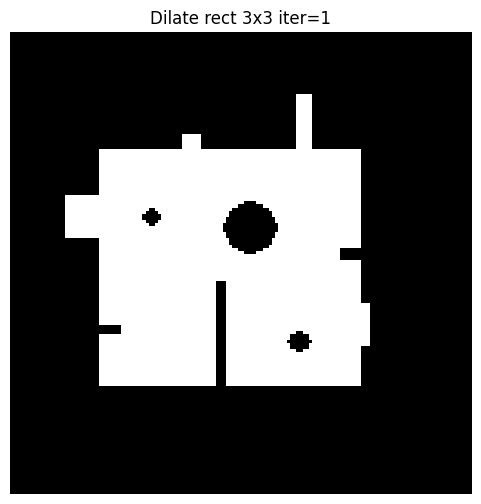

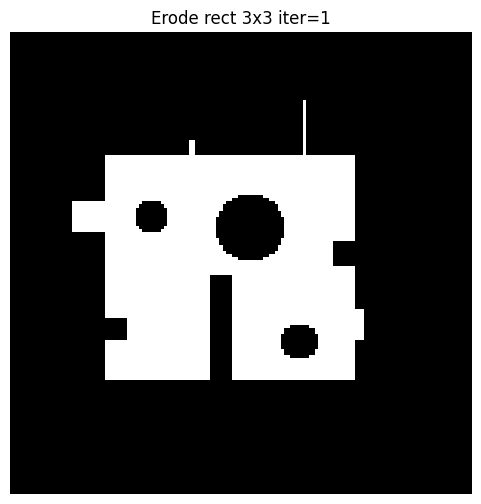

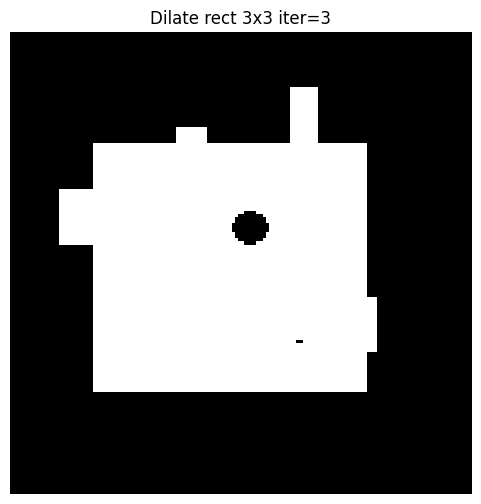

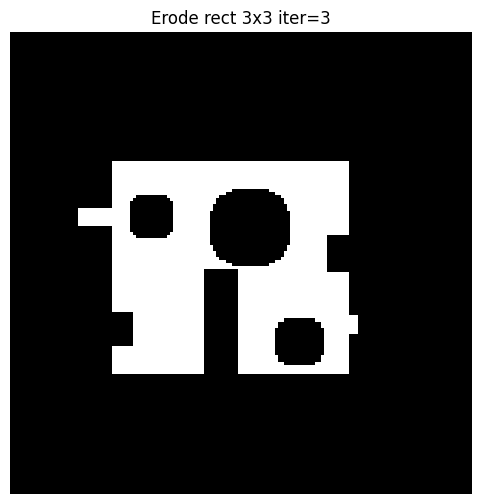

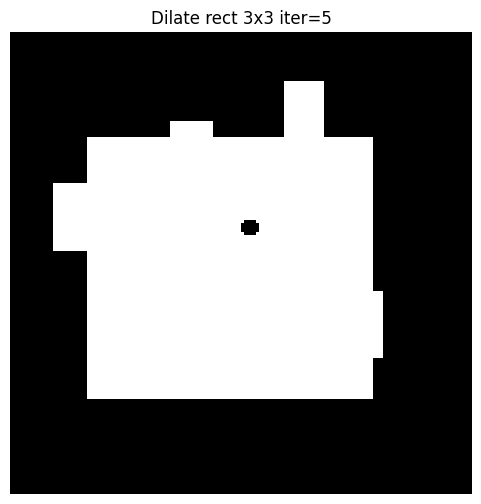

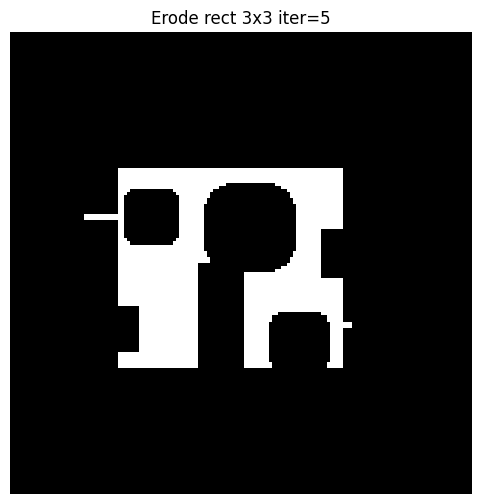

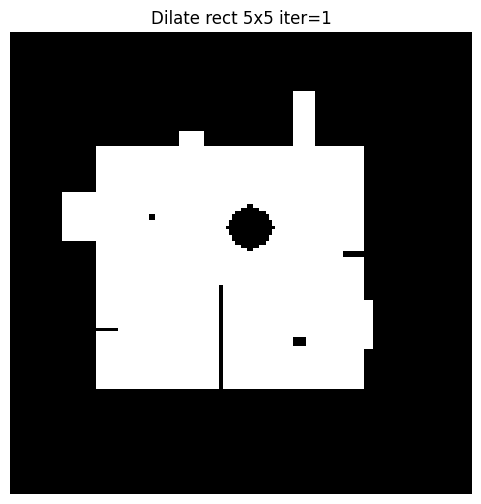

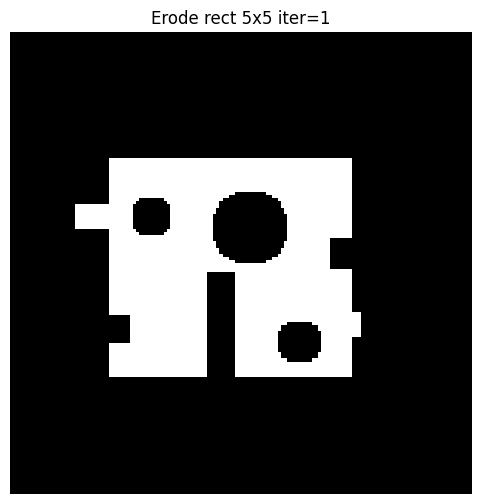

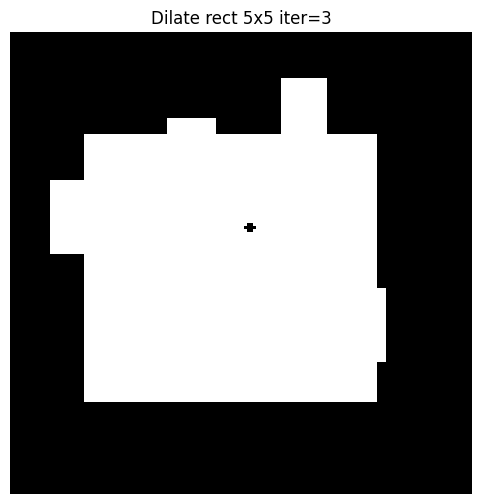

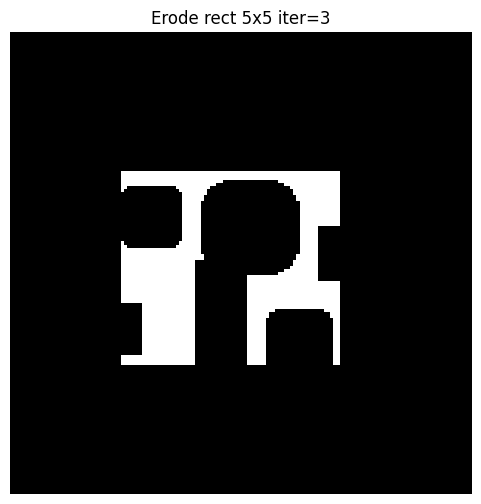

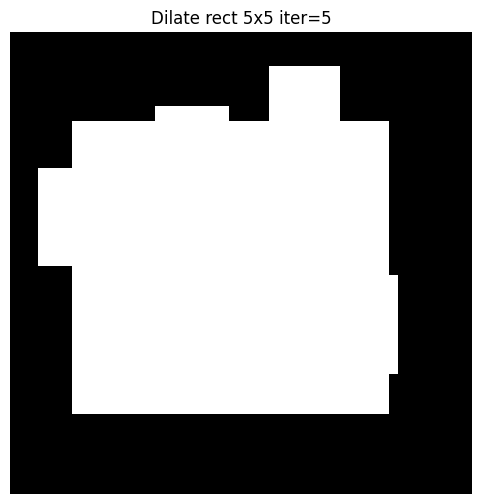

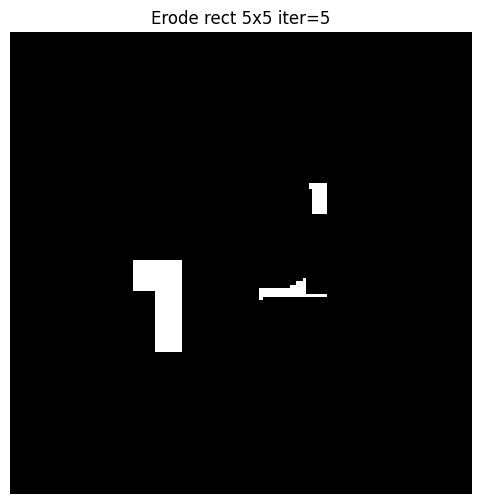

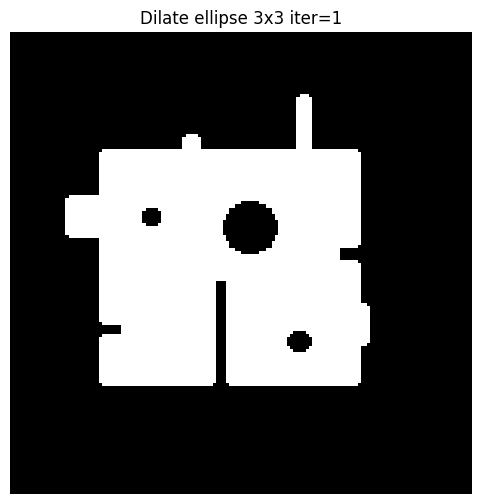

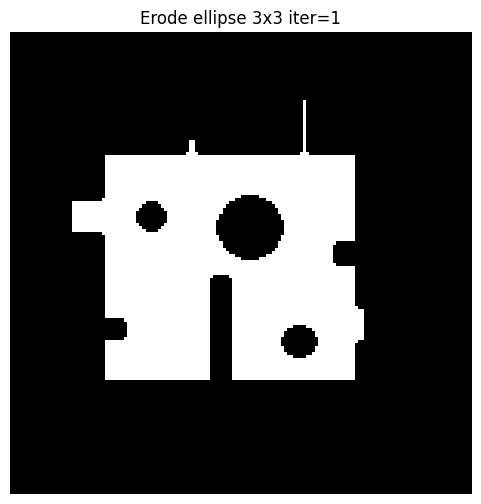

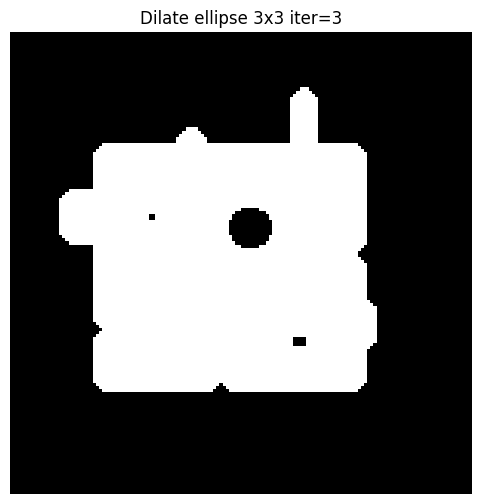

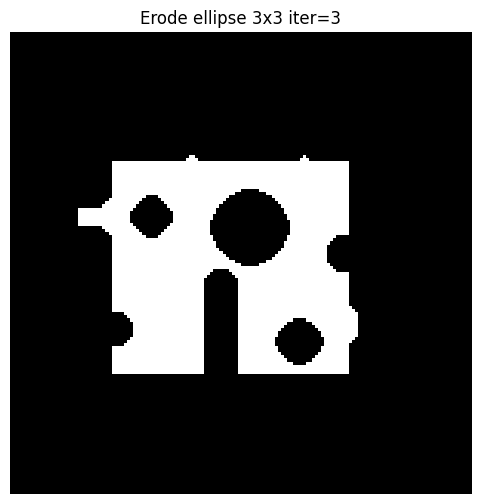

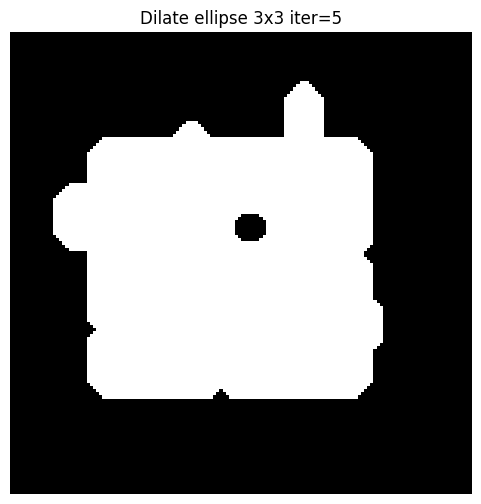

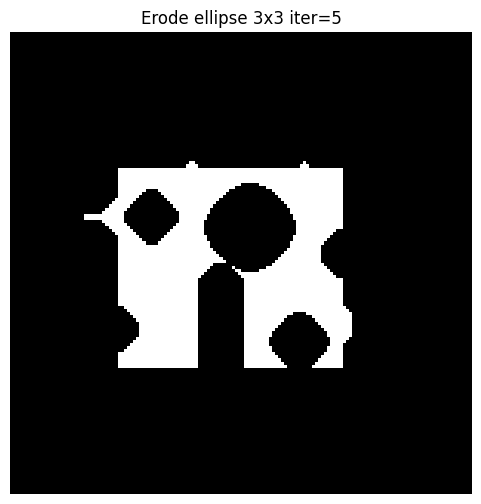

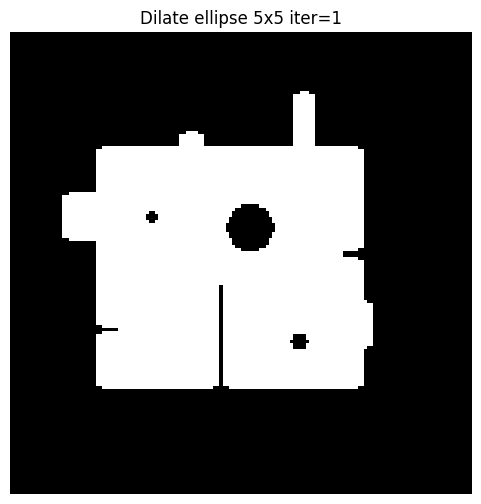

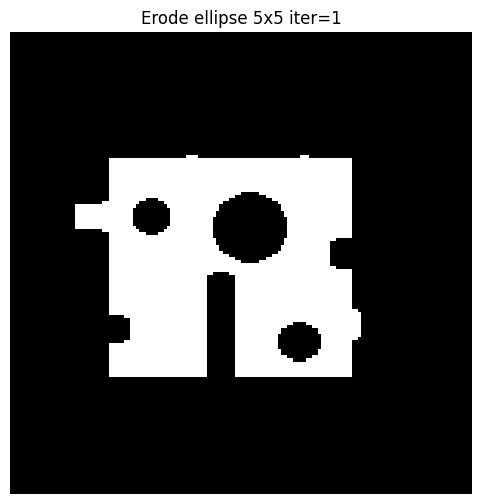

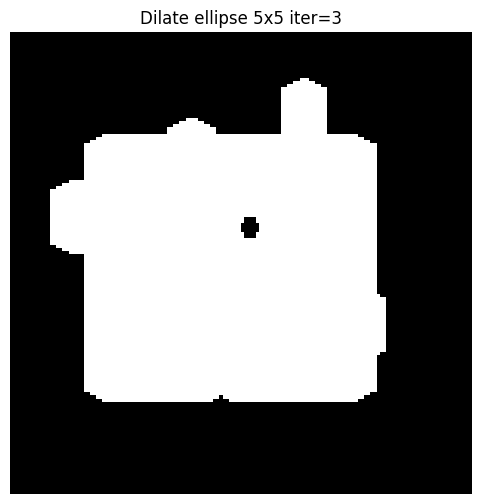

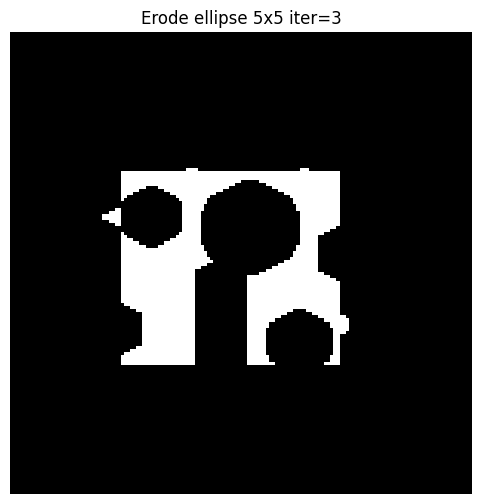

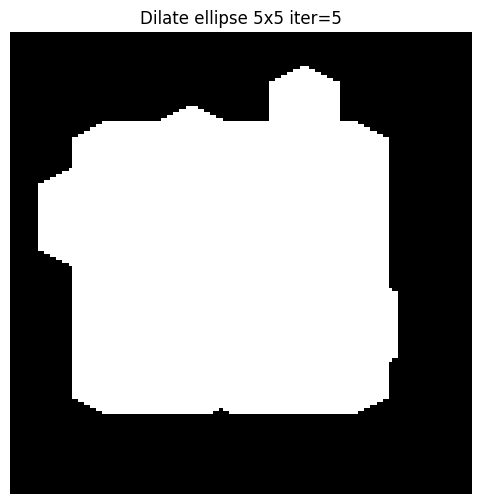

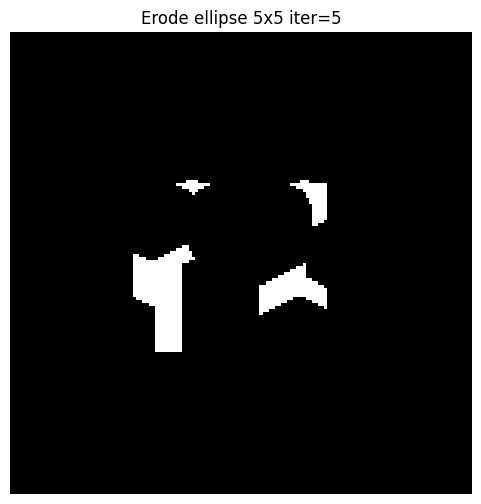

In [ ]:
# Применяем дилатацию и эрозию
for shape_name, shape_val in shapes.items():
    for size in sizes:
        kernel = cv2.getStructuringElement(shape_val, (size, size))
        for it in iterations_list:
            # Дилатация
            dil = cv2.dilate(img_bin, kernel, iterations=it)
            show_and_save(dil,
                         f'Dilate {shape_name} {size}x{size} iter={it}',
                         f'results/dilate_{shape_name}_{size}_iter{it}.jpg')
            # Эрозия
            er = cv2.erode(img_bin, kernel, iterations=it)
            show_and_save(er,
                         f'Erode {shape_name} {size}x{size} iter={it}',
                         f'results/erode_{shape_name}_{size}_iter{it}.jpg')

**Пояснения к результатам:**
 - Дилатация расширяет белые области, заполняет мелкие чёрные дыры.
 - Эрозия, наоборот, сужает белые объекты, убирает мелкие белые шумы.
 - Чем больше размер ядра и количество итераций, тем сильнее эффект.
 - Прямоугольник даёт наибольшее изменение, эллипс — более гладкие края, крест — эффект "звёздочки".

In [ ]:
# Задания 2–4. Открытие, закрытие и их последовательные эквиваленты
# Выберем одно изображение и ядро для демонстрации
img = img_bin.copy()
kernel_cross3 = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
kernel_rect5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

In [ ]:
# Открытие (последовательное применение эрозии, затем дилатация)
open_cv = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_cross3, iterations=1)
open_seq = cv2.dilate(cv2.erode(img, kernel_cross3, iterations=1),
                      kernel_cross3, iterations=1)

In [ ]:
# Закрытие (последовательное применение дилатации, затем эрозии)
close_cv = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel_rect5, iterations=1)
close_seq = cv2.erode(cv2.dilate(img, kernel_rect5, iterations=1),
                      kernel_rect5, iterations=1)

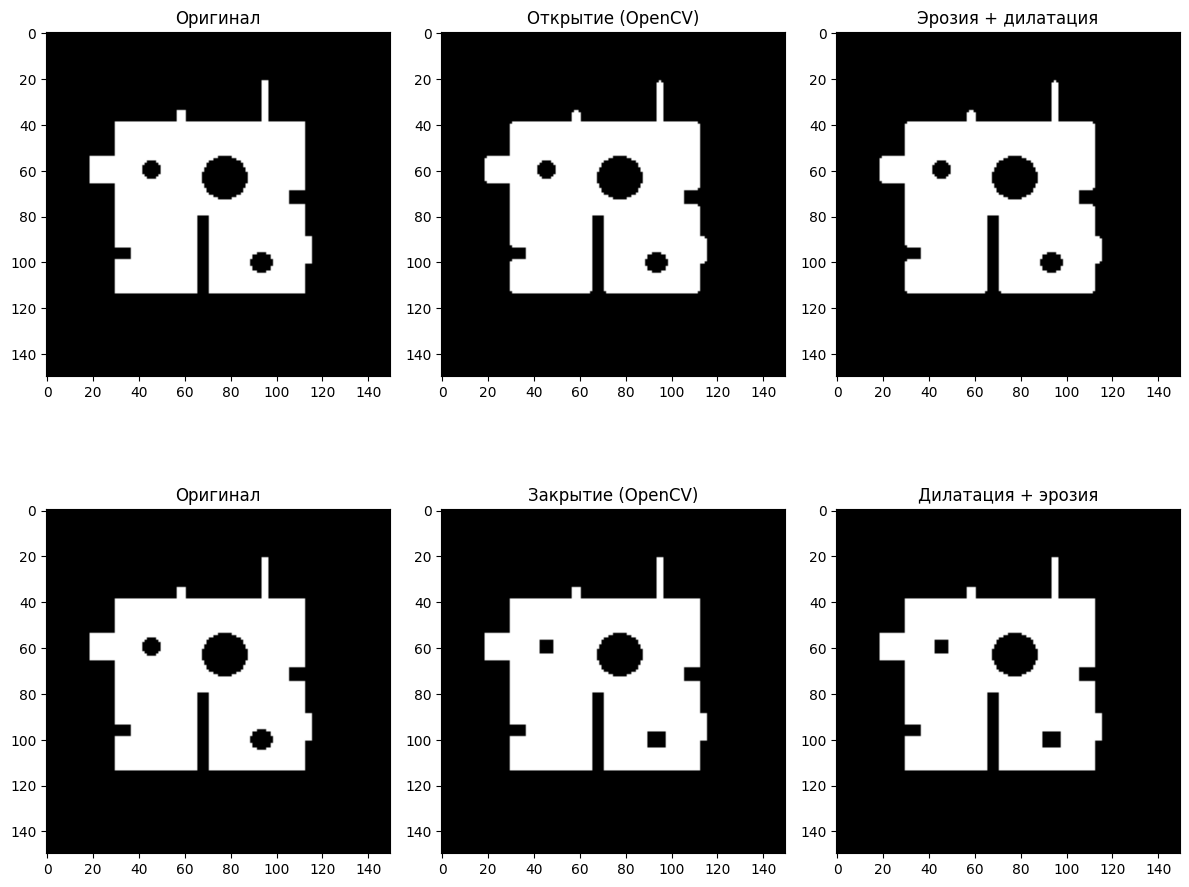

In [ ]:
# Визуализация
plt.figure(figsize=(12,10))
plt.subplot(231), plt.imshow(img, 'gray'), plt.title('Оригинал')
plt.subplot(232), plt.imshow(open_cv, 'gray'), plt.title('Открытие (OpenCV)')
plt.subplot(233), plt.imshow(open_seq, 'gray'), plt.title('Эрозия + дилатация')
plt.subplot(234), plt.imshow(img, 'gray'), plt.title('Оригинал')
plt.subplot(235), plt.imshow(close_cv, 'gray'), plt.title('Закрытие (OpenCV)')
plt.subplot(236), plt.imshow(close_seq, 'gray'), plt.title('Дилатация + эрозия')
plt.tight_layout()
plt.savefig('results/open_close_comparison.jpg')
plt.show()

In [ ]:
# Задание 5. Выделение границы A - er(A,B)

# Функция выделения границы
def boundary(img, kernel):
    eroded = cv2.erode(img, kernel)
    return cv2.subtract(img, eroded) # A - er(A,B)

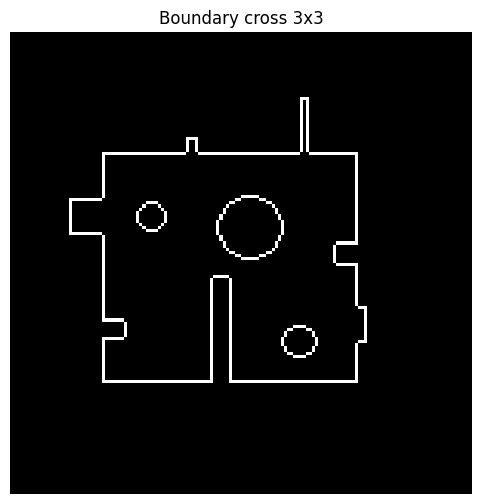

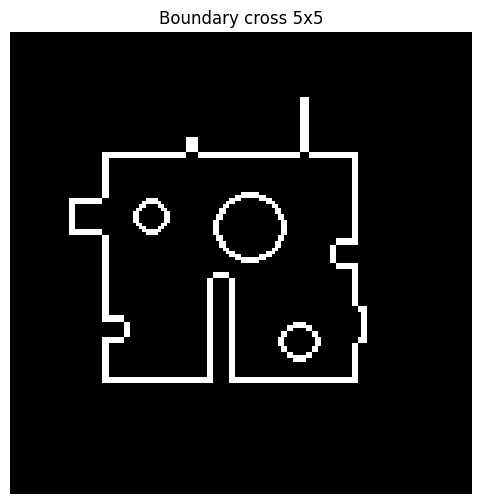

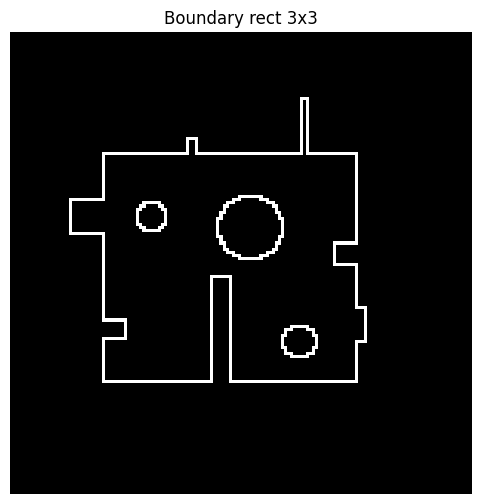

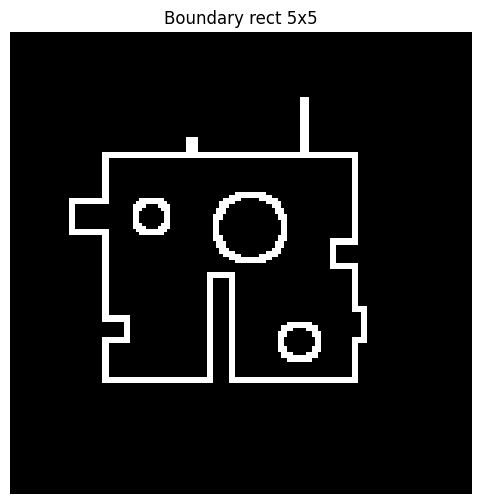

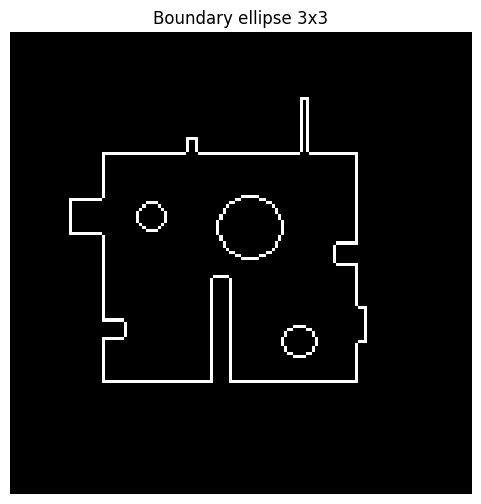

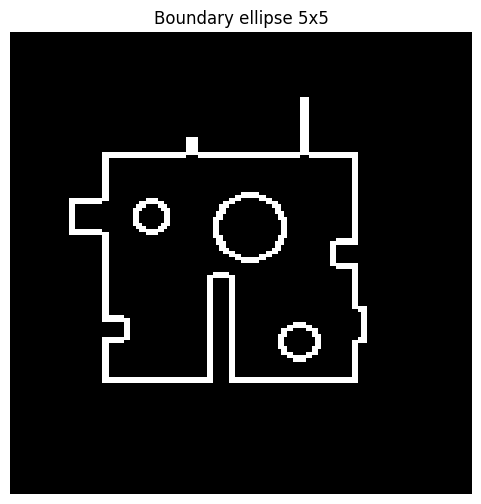

In [ ]:
# Экспериментируем с разными ядрами на Morph.jpg
boundaries = {}
for shape_name, shape_val in shapes.items():
    for size in [3,5]:
        kernel = cv2.getStructuringElement(shape_val, (size, size))
        b = boundary(img_bin, kernel)
        boundaries[f'{shape_name}_{size}'] = b
        show_and_save(b,
                     f'Boundary {shape_name} {size}x{size}',
                     f'results/boundary_{shape_name}_{size}.jpg')

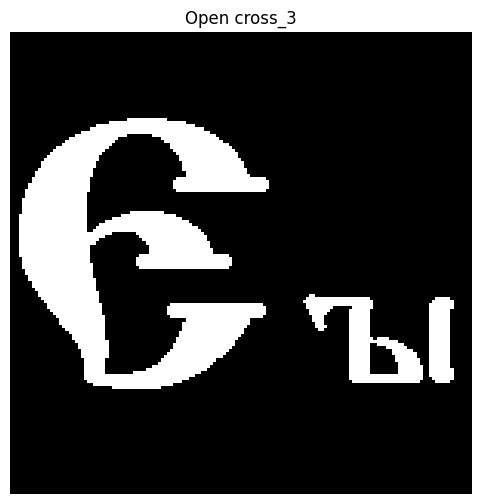

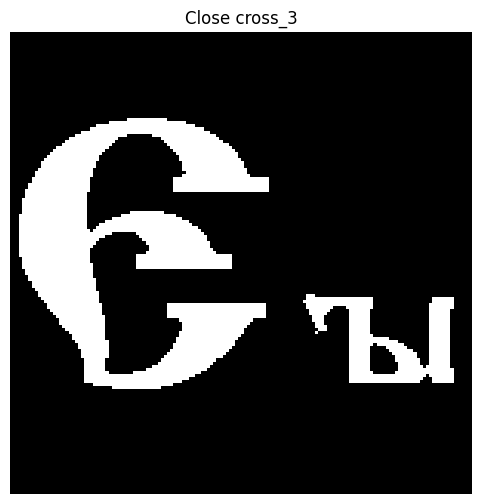

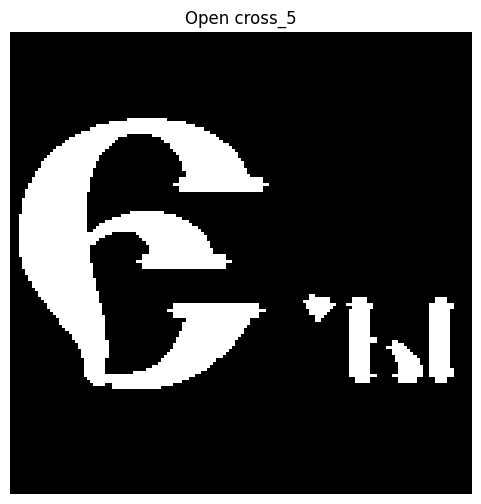

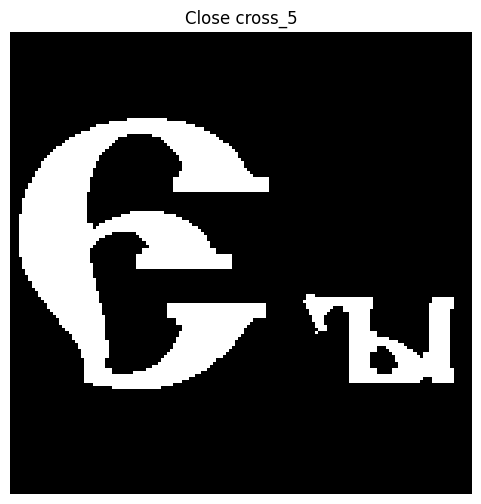

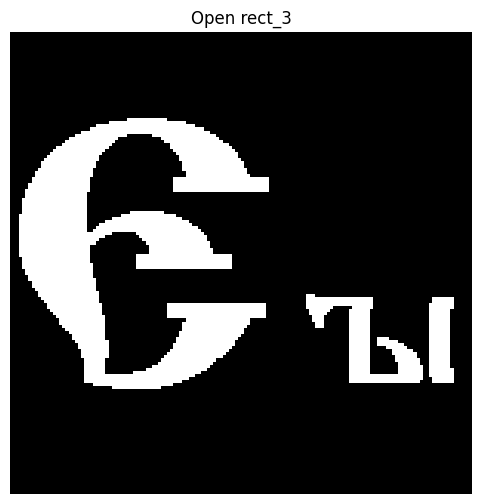

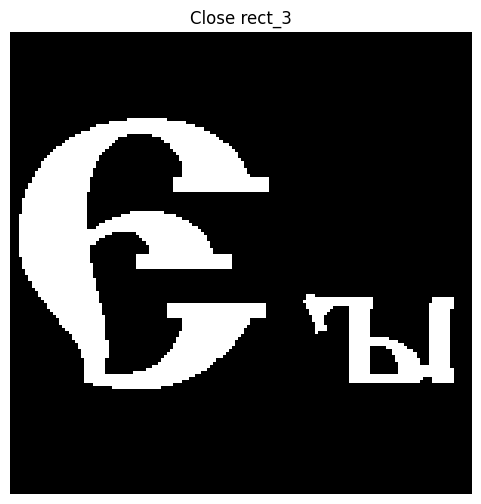

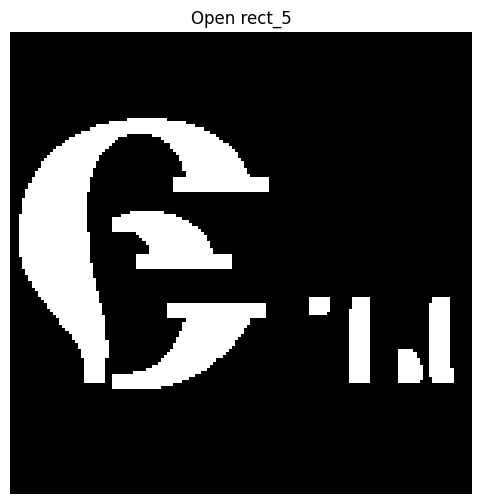

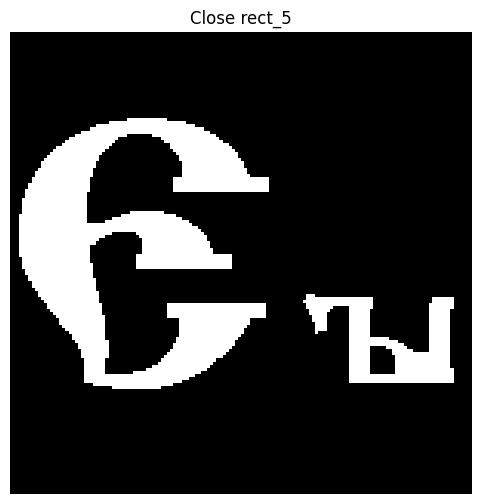

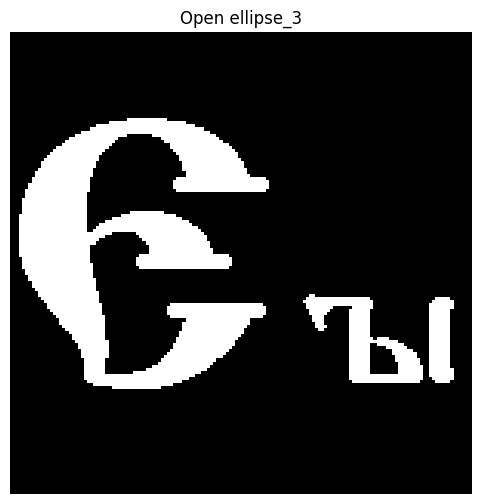

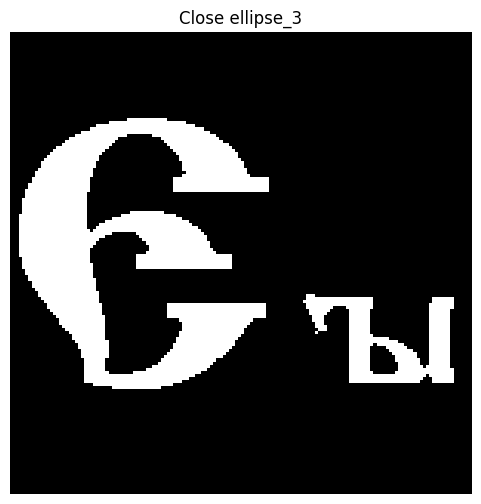

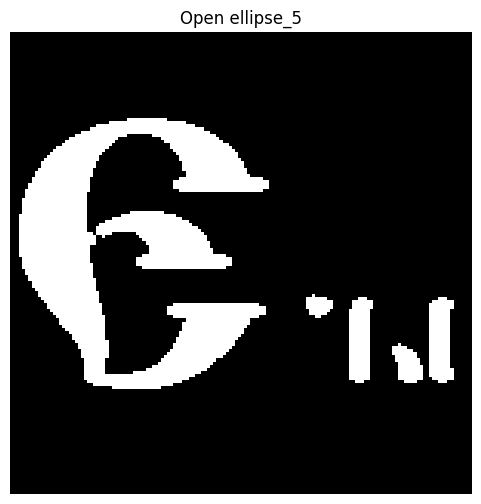

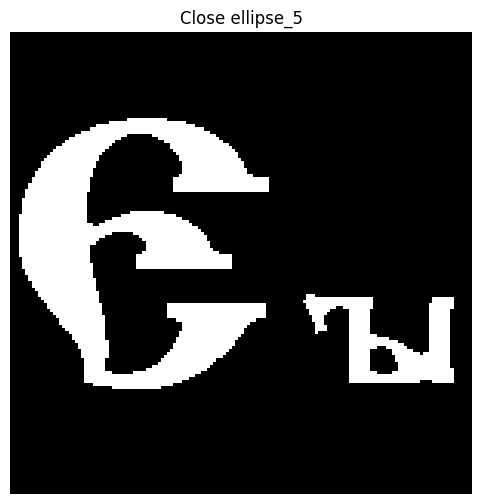

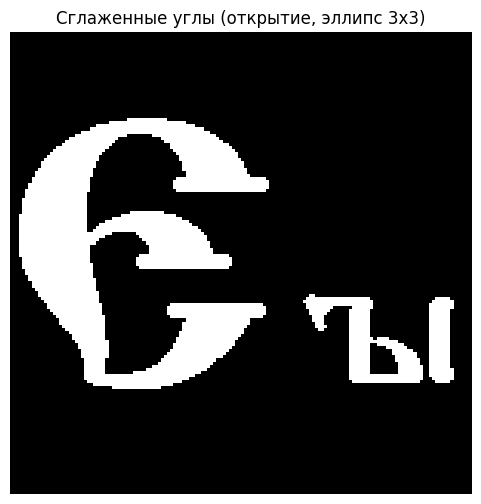

Наилучший результат: операция открытия с эллиптическим ядром 3x3
Эллипс даёт изотропное сглаживание, не создаёт артефактов в виде прямоугольных выступов.


In [ ]:
# 6. Задание 6. Сглаживание углов (morph2.bmp)
if 'morph2.bmp' in available:
    img_m2 = cv2.imread('morph2.bmp', cv2.IMREAD_GRAYSCALE)
    _, m2_bin = cv2.threshold(img_m2, 127, 255, cv2.THRESH_BINARY)

    # Перебор ядер и операций
    best = None
    best_score = 0
    for shape_name, shape_val in shapes.items():
        for size in [3,5]:
            kernel = cv2.getStructuringElement(shape_val, (size, size))
            # Пробуем открытие (убирает выступы)
            opened = cv2.morphologyEx(m2_bin, cv2.MORPH_OPEN, kernel)
            # Пробуем закрытие (заполняет впадины)
            closed = cv2.morphologyEx(m2_bin, cv2.MORPH_CLOSE, kernel)

            # Сохраняем все варианты
            show_and_save(opened, f'Open {shape_name}_{size}', f'results/m2_open_{shape_name}_{size}.jpg')
            show_and_save(closed, f'Close {shape_name}_{size}', f'results/m2_close_{shape_name}_{size}.jpg')

    # Визуальный анализ: скорее всего, лучше всего работает открытие с эллипсом 3x3
    kernel_best = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    smooth = cv2.morphologyEx(m2_bin, cv2.MORPH_OPEN, kernel_best)
    show_and_save(smooth, 'Сглаженные углы (открытие, эллипс 3x3)', 'results/m2_smoothed.jpg')
    print("Наилучший результат: операция открытия с эллиптическим ядром 3x3")
    print("Эллипс даёт изотропное сглаживание, не создаёт артефактов в виде прямоугольных выступов.")
else:
    print("morph2.bmp не загружен, задание 6 пропущено.")

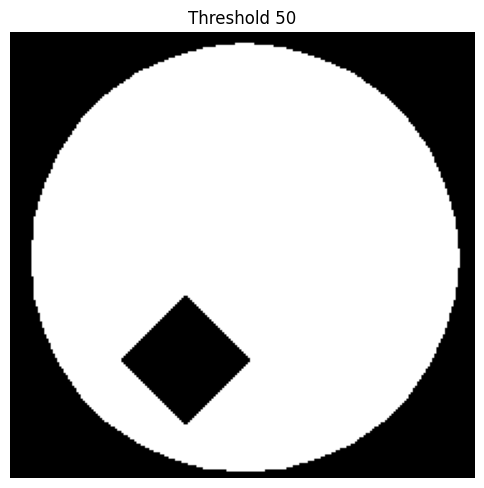

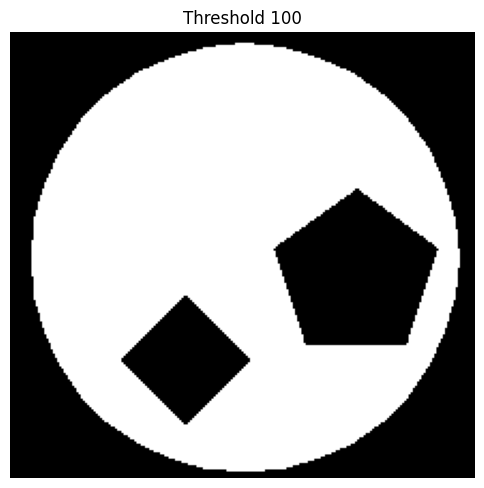

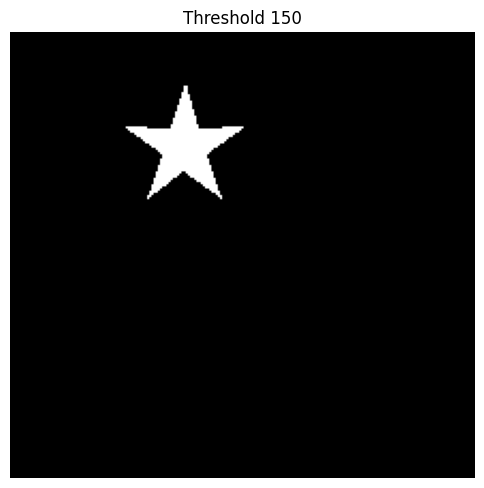

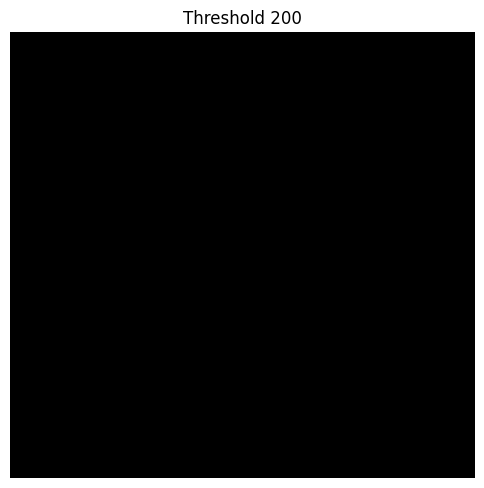

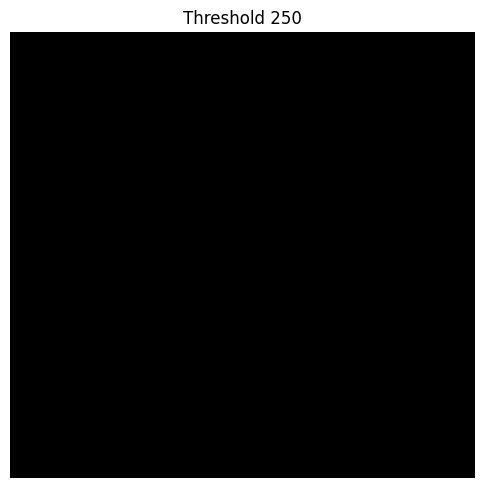

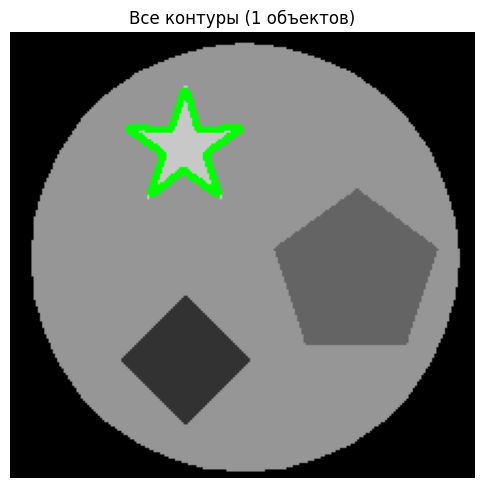

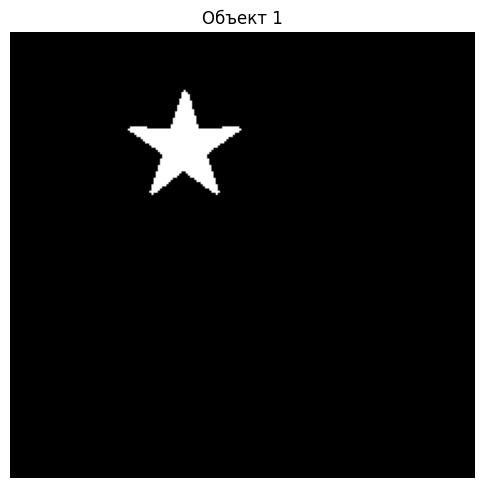

Найдено 1 объектов.
Фильтры: пороговая бинаризация + морфологическое открытие (эллипс 3x3) для удаления шума.


In [ ]:
# 7. Задание 7. Бинаризация и контуры (morph3.bmp)
if 'morph3.bmp' in available:
    img_m3 = cv2.imread('morph3.bmp', cv2.IMREAD_GRAYSCALE)
    # Пробуем разные пороги
    thresholds = [50, 100, 150, 200, 250]
    for th in thresholds:
        _, bin_th = cv2.threshold(img_m3, th, 255, cv2.THRESH_BINARY)
        show_and_save(bin_th, f'Threshold {th}', f'results/m3_thresh_{th}.jpg')

    # Выбираем порог, при котором объекты хорошо отделены (например, 150)
    _, bin_m3 = cv2.threshold(img_m3, 150, 255, cv2.THRESH_BINARY)
    # Морфологическое открытие для удаления шума
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    cleaned = cv2.morphologyEx(bin_m3, cv2.MORPH_OPEN, kernel, iterations=1)

    # Поиск контуров
    contours, hierarchy = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Рисуем все контуры на копии
    img_color = cv2.cvtColor(img_m3, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(img_color, contours, -1, (0,255,0), 2)
    show_and_save(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB),
                  f'Все контуры ({len(contours)} объектов)',
                  'results/m3_all_contours.jpg',
                  cmap=None)

    # Выделяем несколько отдельных объектов (первые 5)
    for i, cnt in enumerate(contours[:5]):
        mask = np.zeros_like(cleaned)
        cv2.drawContours(mask, [cnt], -1, 255, -1)
        obj = cv2.bitwise_and(img_m3, img_m3, mask=mask)
        show_and_save(obj, f'Объект {i+1}', f'results/m3_object_{i+1}.jpg')

    print(f"Найдено {len(contours)} объектов.")
    print("Фильтры: пороговая бинаризация + морфологическое открытие (эллипс 3x3) для удаления шума.")
else:
    print("morph3.bmp не загружен")

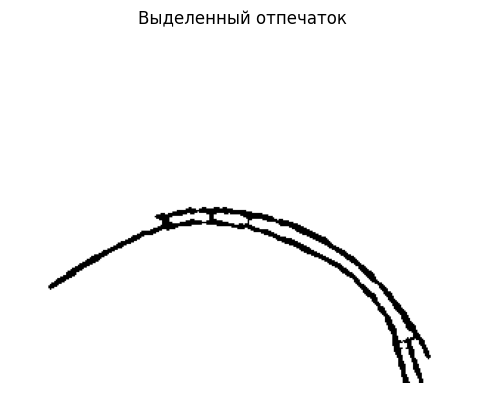

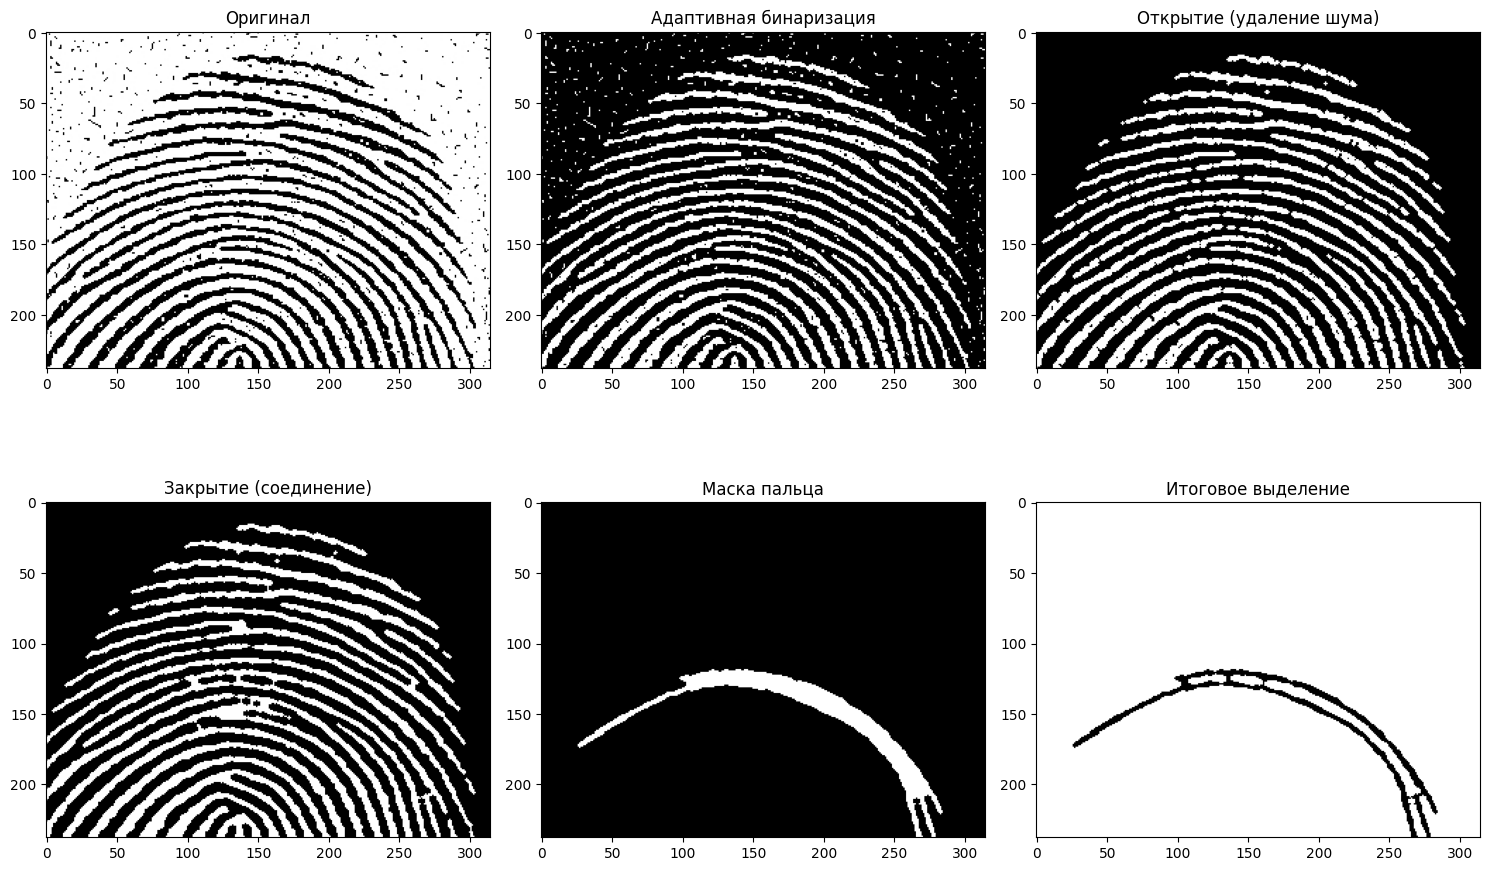

In [ ]:
# Задание 8. Выделение отпечатка пальца (Fingerprint.jpg)

if 'Fingerprint.jpg' in available:
    fp = cv2.imread('Fingerprint.jpg', cv2.IMREAD_GRAYSCALE)
    # 1. Адаптивная бинаризация для учёта неравномерной освещённости
    binary = cv2.adaptiveThreshold(fp, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 10)

    # 2. Удаление шума (мелких точек) открытием
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    denoised = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

    # 3. Закрытие для соединения разрывов в линиях
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    closed = cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, kernel_close, iterations=1)

    # 4. Удаление фонового шума — удаляем слишком крупные объекты (не палец)
    # Для этого найдём контуры и оставим только самый крупный (область пальца)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        mask = np.zeros_like(closed)
        cv2.drawContours(mask, [largest], -1, 255, -1)
        result = cv2.bitwise_and(closed, mask)

        # 5. Инвертируем для визуализации (белые линии на чёрном)
        final = cv2.bitwise_not(result)
    else:
        final = closed

    show_and_save(final, 'Выделенный отпечаток', 'results/fingerprint_extracted.jpg')

    # Покажем промежуточные этапы
    plt.figure(figsize=(15,10))
    plt.subplot(231), plt.imshow(fp, 'gray'), plt.title('Оригинал')
    plt.subplot(232), plt.imshow(binary, 'gray'), plt.title('Адаптивная бинаризация')
    plt.subplot(233), plt.imshow(denoised, 'gray'), plt.title('Открытие (удаление шума)')
    plt.subplot(234), plt.imshow(closed, 'gray'), plt.title('Закрытие (соединение)')
    plt.subplot(235), plt.imshow(mask, 'gray'), plt.title('Маска пальца')
    plt.subplot(236), plt.imshow(final, 'gray'), plt.title('Итоговое выделение')
    plt.tight_layout()
    plt.savefig('results/fingerprint_steps.jpg')
    plt.show()
else:
    print("Fingerprint.jpg не загружен, задание 8 пропущено.")